In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create Dataset

In [2]:
from sklearn.datasets import make_blobs


X, y = make_blobs(
    n_samples=300,
    centers=[
        [2,2],
        [8,8],
        [2,8]
    ],
    cluster_std=0.5,
    random_state=42
)


df = pd.DataFrame(
    X,
    columns=[
        "Feature_1",
        "Feature_2"
    ]
)


df.head()

,Feature_1,Feature_2
0,1.404348,2.328277
1,1.727809,2.055461
2,2.060148,8.257219
3,7.509246,8.231052
4,2.029104,1.428515


# Add Noise Points (Outliers)

In [3]:
noise = np.array([
    [10,2],
    [12,5],
    [6,1],
    [9,12],
    [0,10]
])


X = np.vstack(
    [
        X,
        noise
    ]
)


df = pd.DataFrame(
    X,
    columns=[
        "Feature_1",
        "Feature_2"
    ]
)


df.shape

(305, 2)

# Visualize Original Data

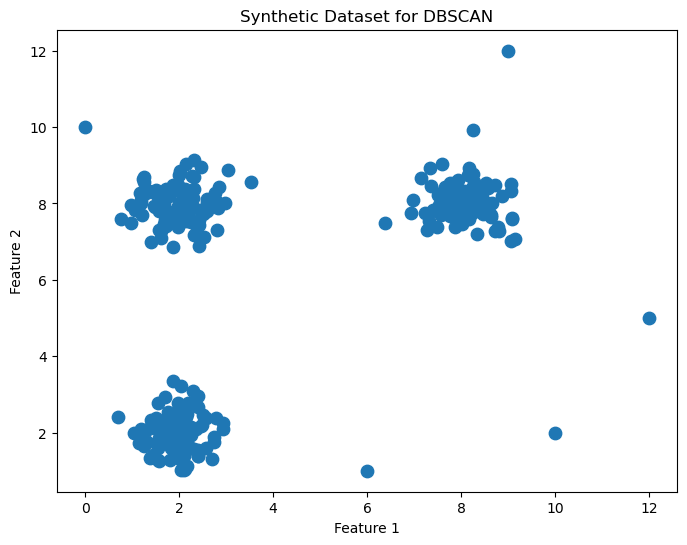

In [4]:
plt.figure(figsize=(8,6))


plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    s=80
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title(
    "Synthetic Dataset for DBSCAN"
)


plt.show()

# Apply DBSCAN

In [5]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)


labels = dbscan.fit_predict(df)

In [6]:
df["Cluster"] = labels


df.head()

,Feature_1,Feature_2,Cluster
0,1.404348,2.328277,0
1,1.727809,2.055461,0
2,2.060148,8.257219,1
3,7.509246,8.231052,2
4,2.029104,1.428515,0


# Visualize DBSCAN Clusters

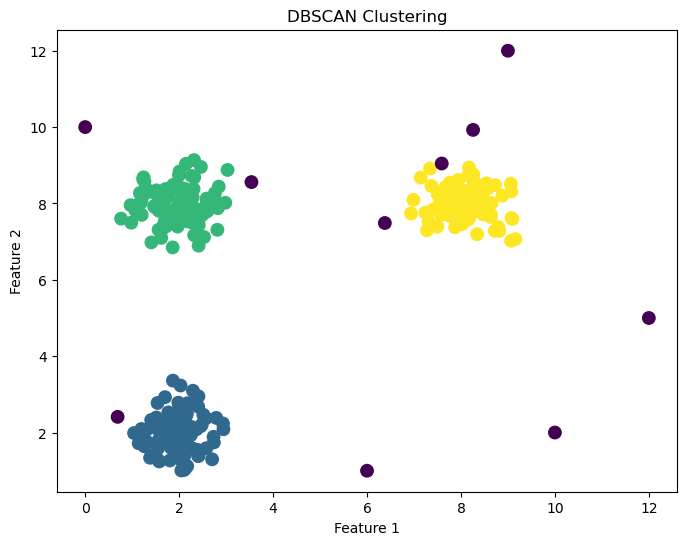

In [7]:
plt.figure(figsize=(8,6))


plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=df["Cluster"],
    s=80
)


plt.xlabel("Feature 1")

plt.ylabel("Feature 2")


plt.title(
    "DBSCAN Clustering"
)


plt.show()

In [8]:
df["Cluster"].value_counts()

Cluster
 0    99
 1    99
 2    97
-1    10
Name: count, dtype: int64